In [1]:
# load eigen maps with the 2 models and set up for first screen
import os, sys, glob, pickle
import numpy as np
import pandas as pd
import torch

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap, MPRAHead, AlphaGenomeMPRA

eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CKPT_DIR = os.path.join(REPO, 'models')

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
CTS = ['HepG2', 'K562']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

with open(os.path.join(REPO, 'virtual_perturbations/libraries/hippo_target_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
lib = target_lib['df']
reps = {cond: int(lib[lib['condition'] == cond].iloc[0]['seq_idx'])
        for cond in ['same-same', 'diff-diff', 'same-diff']}
sub_idx = [reps[name] for name in ['same-same', 'diff-diff', 'same-diff']]
print('reps:', reps)

def _load_model_patched(self, ct, squeeze=False):
    eigen_steering._load_heavy_deps()
    name = self.model_names[ct]
    ckpt_path = os.path.join(CKPT_DIR, name, 'best_stage2.pt')
    print(f"  Loading {ct}: {ckpt_path}")
    enc = eigen_steering.AlphaGenome.from_pretrained(eigen_steering.WEIGHTS_PATH, device='cpu')
    eigen_steering.remove_all_heads(enc)
    hd = MPRAHead()
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    return AlphaGenomeMPRA(enc, hd, squeeze=squeeze).to(self.device).eval()

EigenMap._load_model = _load_model_patched
models = em._load_models()
print(f'{len(df)} seqs on {DEVICE}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
reps: {'same-same': 53997, 'diff-diff': 26012, 'same-diff': 56772}
AlphaGenome patches applied (all functional activations -> nn.Module).
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt
56975 seqs on cuda


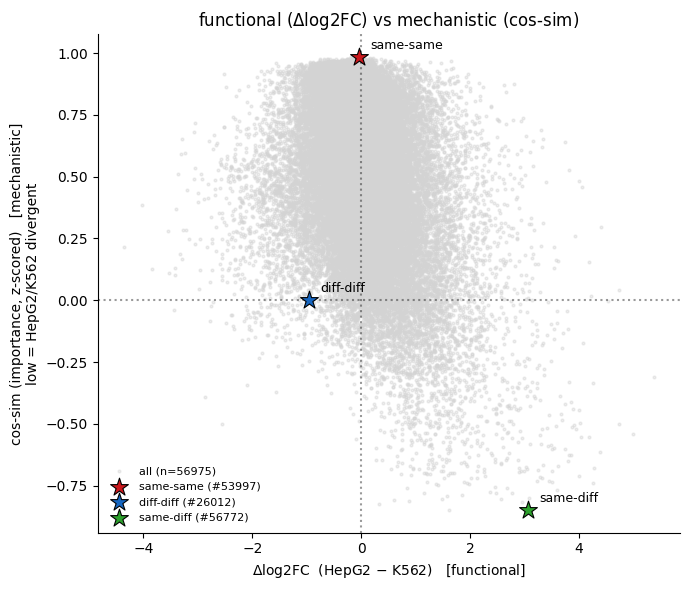

In [29]:
# cos-sim (mechanistic, y) vs delta-log2FC (functional, x), 3 focus seqs marked                                                                                                                                                                                                                                                                                                                                           
cossim = em.cosine_similarity(mode='importance', zscore=True)
diffs  = df['HepG2_log2FC'].values - df['K562_log2FC'].values                                                                                                                                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                                                                                                                                                                                        
fin = np.isfinite(cossim) & np.isfinite(diffs)                                                                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(7, 6))                                                                                                                                                                                                                                                                                                                                                                                    
ax.scatter(diffs[fin], cossim[fin], s=4, color='lightgray', alpha=0.4,
            rasterized=True, label=f'all (n={fin.sum()})')                                                                                                                                                                                                                                                                                                                                                                 
                                                                                                                                                                                                                                                                                                                                                                                                                        
focus_color = {'same-same': '#cb181d', 'diff-diff': '#1565C0', 'same-diff': '#2ca02c'}                                                                                                                                                                                                                                                                                                                                    
for name, idx in groups:                                                                                                                                                                                                                                                                                                                                                                                                  
    ax.scatter([diffs[idx]], [cossim[idx]], s=180, marker='*',                                                                                                                                                                                                                                                                                                                                                            
                color=focus_color[name], edgecolors='black', linewidth=0.8,                                                                                                                                                                                                                                                                                                                                                
                zorder=5, label=f'{name} (#{idx})')
    ax.annotate(name, (diffs[idx], cossim[idx]),                                                                                                                                                                                                                                                                                                                                                                          
                textcoords='offset points', xytext=(8, 6), fontsize=9)                                                                                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                                                                                                                        
ax.axhline(0, color='k', ls=':', alpha=0.4)                                                                                                                                                                                                                                                                                                                                                                               
ax.axvline(0, color='k', ls=':', alpha=0.4)                                                                                                                                                                                                                                                                                                                                                                               
ax.set_xlabel(r'$\Delta$log2FC  (HepG2 − K562)   [functional]')                                                                                                                                                                                                                                                                                                                                                           
ax.set_ylabel('cos-sim (importance, z-scored)   [mechanistic]\nlow = HepG2/K562 divergent')                                                                                                                                                                                                                                                                                                                               
ax.set_title(r'functional ($\Delta$log2FC) vs mechanistic (cos-sim)')                                                                                                                                                                                                                                                                                                                                                     
ax.legend(fontsize=8, loc='best', frameon=False)                                                                                                                                                                                                                                                                                                                                                                          
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)                                                                                                                                                                                                                                                                                                                                                              
plt.tight_layout(); plt.show()

In [7]:
# run first screen like in k-cee_screen.ipynb
# --- knobs ---
N_RUNS = 100   # independent screen runs per seq
N_TRY  = 50   # random windows tested per run
N_REPS = 10   # dinuc-shuffle replicates per window
WIN    = 4    # KO window size (bp)
# -------------

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle
ENH_LEN = eigen_steering.ENHANCER_LEN
L = em.X.shape[-1]
rng = np.random.default_rng(42)

groups = list(reps.items())
winners = {name: {ct: [] for ct in CTS} for name, _ in groups}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    wt_pred = em._predict_tensor(wt, models=models, batch_size=4)
    wt_p = {ct: float(wt_pred[ct][0]) for ct in CTS}

    for run_i in range(N_RUNS):
        starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_TRY)
        chunks = []
        for s in starts:
            shuf = dinuc_shuf(wt, n=N_REPS,
                              random_state=int(idx)*1_000_000 + run_i*1000 + int(s))[0]
            chim = wt.expand(N_REPS, -1, -1).clone()
            chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
            chunks.append(chim)
        all_chim = torch.cat(chunks, dim=0)
        p = em._predict_tensor(all_chim, models=models, batch_size=128)
        for ct in CTS:
            pm = p[ct].reshape(N_TRY, N_REPS).mean(axis=1)
            impact = np.abs(pm - wt_p[ct])
            winners[name][ct].append(int(starts[int(impact.argmax())]))
    for ct in CTS:
        winners[name][ct] = np.array(winners[name][ct])
        print(f'{name} {ct}: winners = {winners[name][ct].tolist()}')

same-same HepG2: winners = [143, 142, 136, 137, 131, 139, 141, 136, 131, 136, 131, 131, 139, 139, 136, 139, 137, 138, 131, 139, 136, 126, 139, 140, 141, 141, 138, 140, 132, 129, 137, 140, 132, 140, 129, 138, 140, 140, 27, 138, 136, 133, 141, 137, 137, 26, 133, 140, 136, 138, 140, 131, 139, 137, 131, 132, 140, 142, 139, 138, 142, 132, 141, 139, 138, 128, 136, 140, 138, 144, 131, 141, 140, 142, 132, 132, 132, 140, 139, 140, 139, 136, 34, 128, 139, 136, 136, 138, 132, 139, 133, 140, 140, 131, 129, 134, 138, 132, 141, 138]
same-same K562: winners = [143, 142, 136, 137, 131, 139, 141, 136, 131, 137, 131, 131, 139, 139, 136, 139, 137, 138, 131, 139, 136, 145, 139, 140, 141, 141, 138, 140, 132, 129, 137, 140, 132, 140, 129, 138, 140, 140, 125, 138, 136, 133, 141, 137, 137, 125, 133, 140, 140, 138, 140, 131, 139, 137, 140, 132, 140, 138, 139, 138, 142, 132, 141, 137, 138, 128, 136, 140, 138, 144, 131, 141, 140, 142, 132, 132, 132, 140, 139, 140, 139, 136, 102, 128, 139, 136, 136, 138, 132, 139

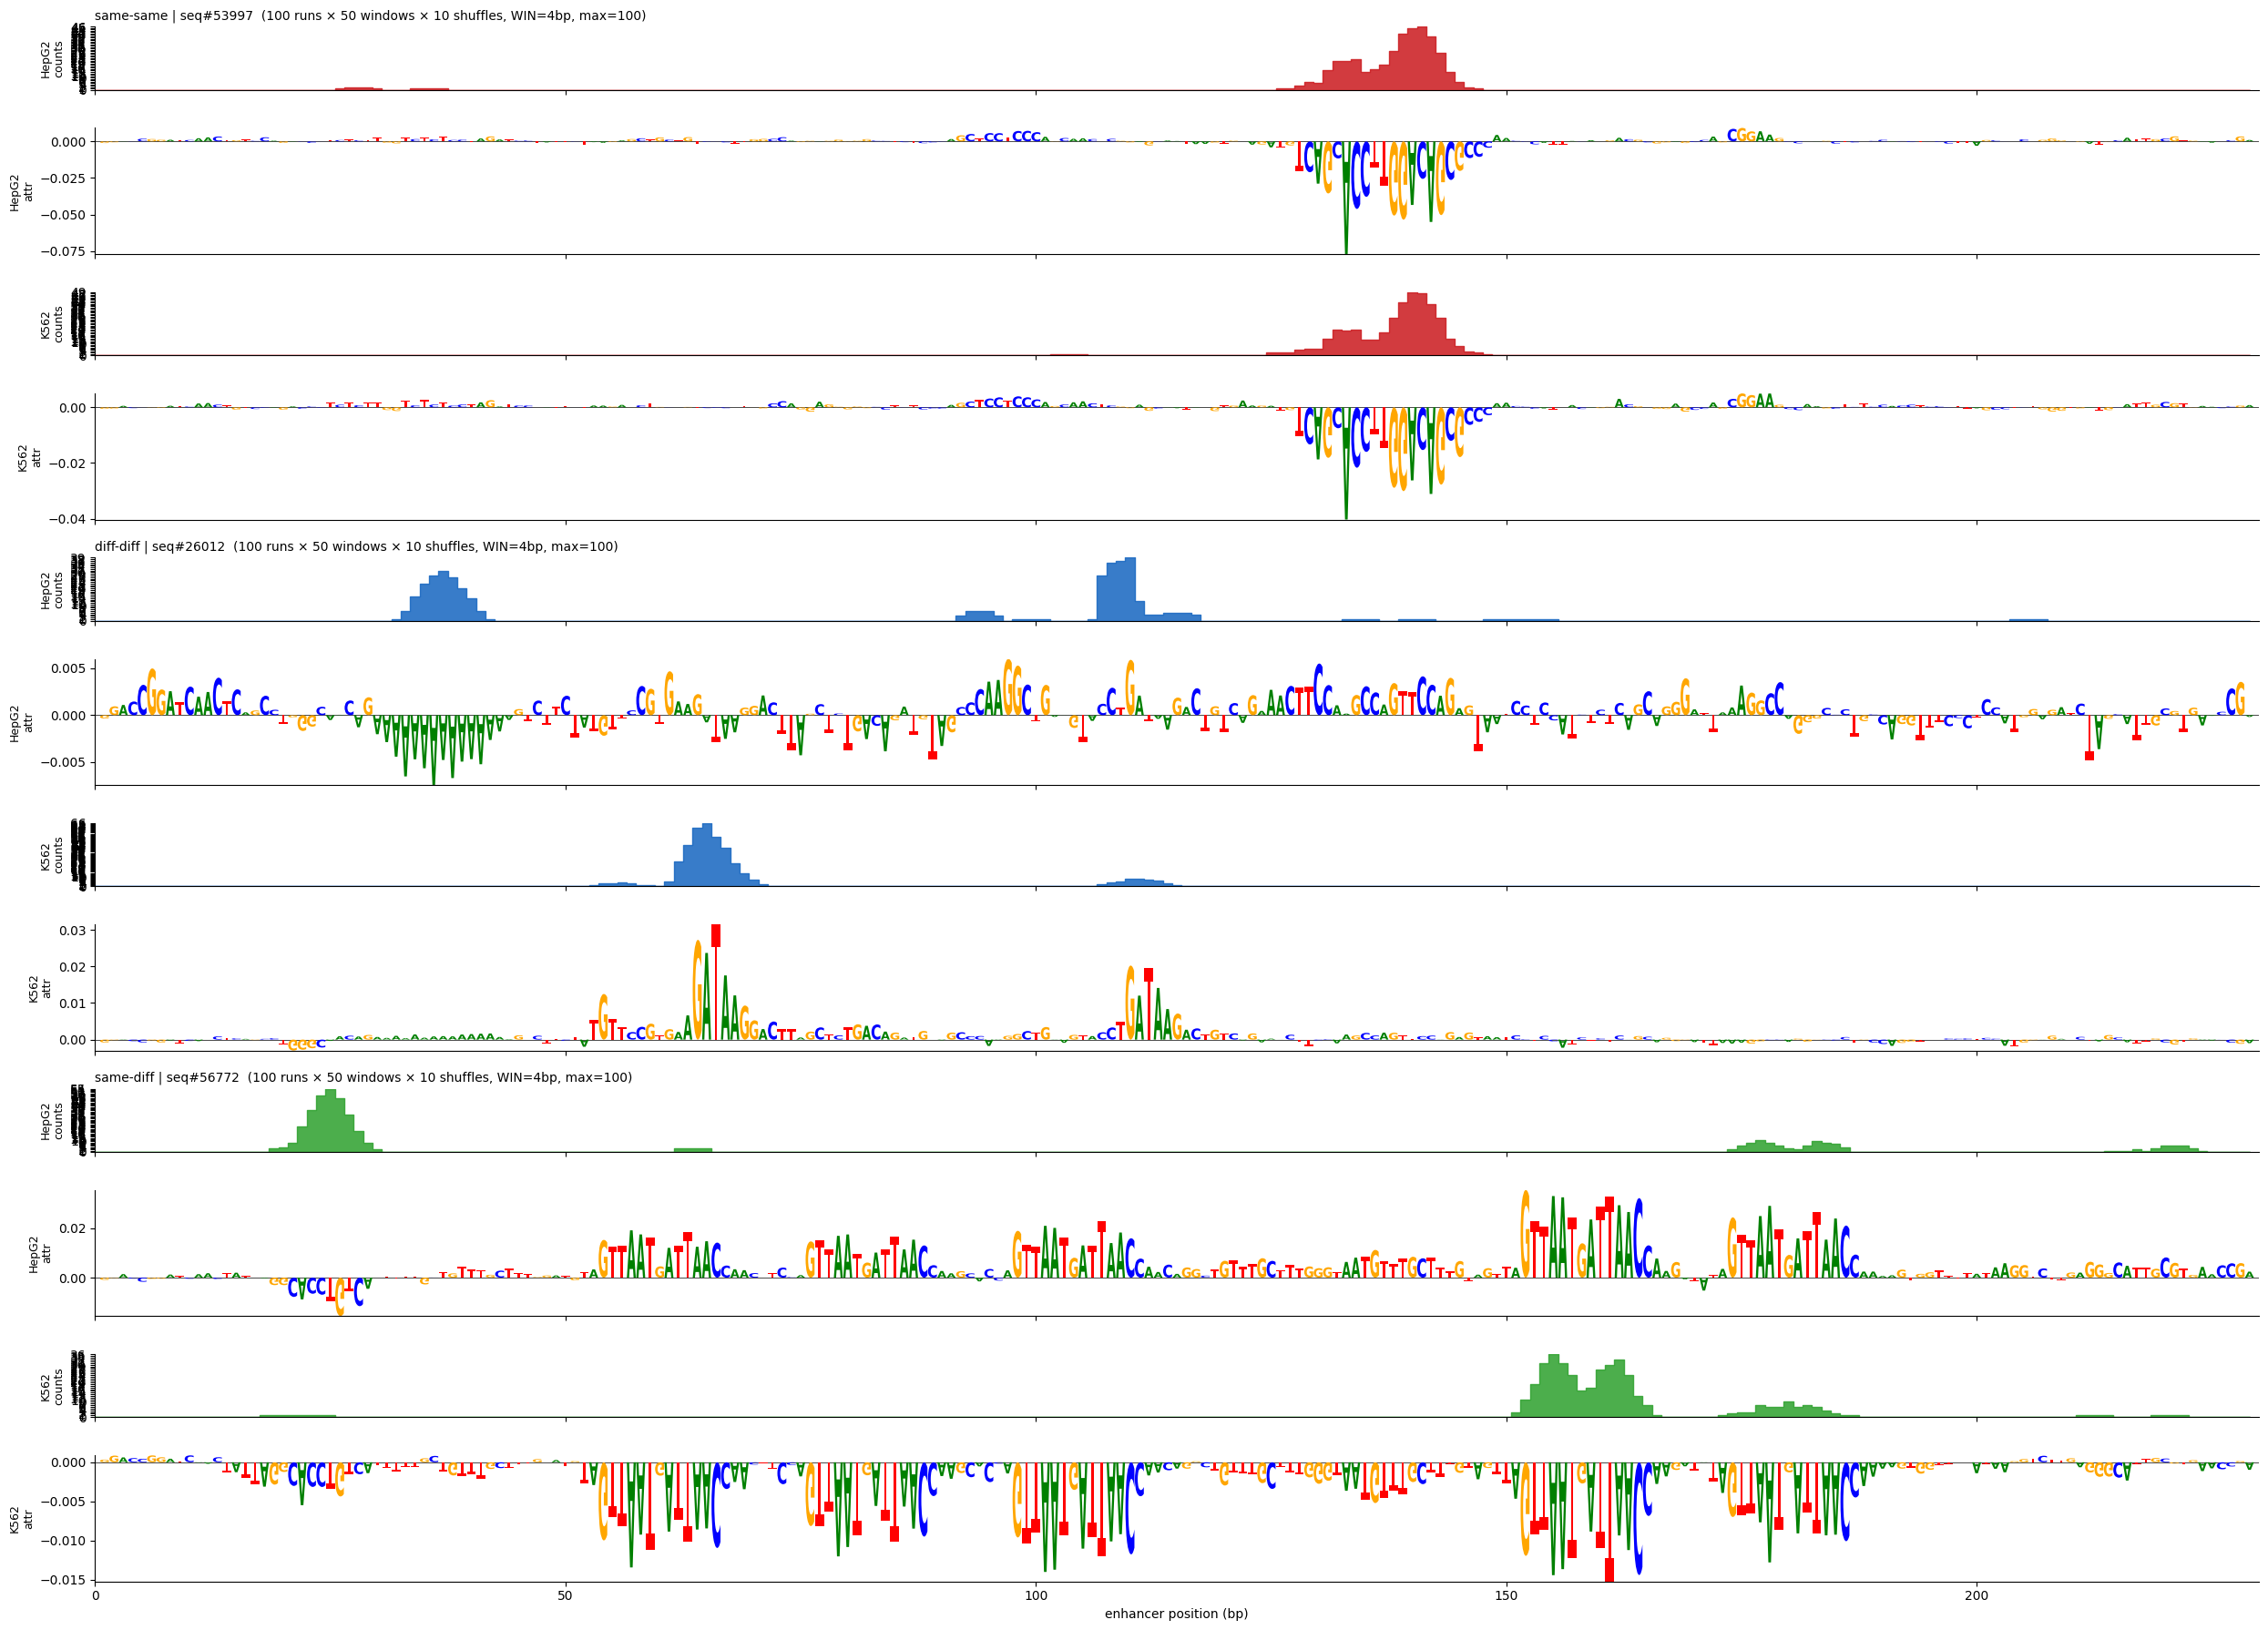

In [27]:
import logomaker as lm
import matplotlib.pyplot as plt

def coverage_counts(starts_arr, win, length):
    """Raw count: # of runs whose winning [s, s+win] covers each position."""
    cov = np.zeros(length, dtype=int)
    for s in starts_arr:
        cov[s:s+win] += 1
    return cov

# --- plot: per seq -> [HepG2 counts, HepG2 logo, K562 counts, K562 logo] ---
group_color = {'same-same': '#cb181d', 'diff-diff': '#1565C0', 'same-diff': '#2ca02c'}
n_seqs   = len(groups)
ROWS_PER = 4
xs = np.arange(ENH_LEN)

fig, axes = plt.subplots(ROWS_PER * n_seqs, 1,
                         figsize=(25, 3 * ROWS_PER * n_seqs / 2),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1, 2, 1, 2] * n_seqs})

for gi, (name, idx) in enumerate(groups):
    base = gi * ROWS_PER
    col  = group_color[name]
    for ci, ct in enumerate(CTS):

        ax_d = axes[base + 2*ci]
        ax_l = axes[base + 2*ci + 1]

        d = coverage_counts(winners[name][ct], WIN, ENH_LEN)
        ax_d.fill_between(xs, d, 0, color=col, alpha=0.85, step='mid')
        ax_d.set_ylim(0, max(int(d.max()), 1))
        ax_d.set_yticks(np.arange(0, max(int(d.max()), 1) + 1))
        ax_d.set_ylabel(f'{ct}\ncounts', fontsize=9)
        if ci == 0:
            ax_d.set_title(f'{name} | seq#{idx}  '
                           f'({N_RUNS} runs × {N_TRY} windows × {N_REPS} shuffles, WIN={WIN}bp, max={N_RUNS})',
                           fontsize=10, loc='left')
        for sp in ('top', 'right'): ax_d.spines[sp].set_visible(False)

        att = em.attr[ct][idx, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax_l)
        ax_l.set_ylabel(f'{ct}\nattr', fontsize=9)
        for sp in ('top', 'right'): ax_l.spines[sp].set_visible(False)

axes[-1].set_xlabel('enhancer position (bp)')
axes[-1].set_xlim(0, ENH_LEN)
plt.tight_layout(); plt.show()

In [9]:
# set up for second screen (just make sure first screen results saved)
OUT = os.path.join(REPO, 'genomic_targets', 'data', 'kcee_forward_screen1.pkl')
with open(OUT, 'wb') as f:
    pickle.dump({
        'winners': {name: {ct: winners[name][ct] for ct in CTS} for name, _ in groups},
        'reps': reps,
        'sub_idx': sub_idx,
        'WIN': WIN, 'N_RUNS': N_RUNS, 'N_TRY': N_TRY, 'N_REPS': N_REPS,
    }, f)
print('saved ->', OUT)

saved -> /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/data/kcee_forward_screen1.pkl


In [11]:
# round-2 screen: each round-1 winner seeds its OWN round-2 run (paired, per-ct)
winners2 = {name: {ct: [] for ct in CTS} for name, _ in groups}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i, w1 in enumerate(winners[name][ct]):
            w1 = int(w1)
            # KO this run's round-1 winner -> per-run starting seq
            wt_ko = wt.clone()
            ko_shuf = dinuc_shuf(wt, n=1, random_state=int(idx)*999 + run_i*7 + w1)[0]
            wt_ko[:, :, w1:w1+WIN] = ko_shuf[:, :, w1:w1+WIN]
            wt_p = float(em._predict_tensor(wt_ko, models=models, batch_size=4)[ct][0])

            # forward screen on top of wt_ko
            starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_TRY)
            chunks = []
            for s in starts:
                shuf = dinuc_shuf(wt_ko, n=N_REPS,
                                  random_state=int(idx)*1_000_000 + run_i*1000 + int(s))[0]
                chim = wt_ko.expand(N_REPS, -1, -1).clone()
                chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
                chunks.append(chim)
            all_chim = torch.cat(chunks, dim=0)
            p = em._predict_tensor(all_chim, models=models, batch_size=128)[ct]
            pm = p.reshape(N_TRY, N_REPS).mean(axis=1)
            impact = np.abs(pm - wt_p)
            winners2[name][ct].append(int(starts[int(impact.argmax())]))
        winners2[name][ct] = np.array(winners2[name][ct])
        print(f'{name} {ct}: r2 winners = {winners2[name][ct].tolist()}')


same-same HepG2: r2 winners = [134, 99, 129, 141, 136, 123, 140, 136, 140, 94, 109, 168, 183, 143, 183, 98, 141, 141, 123, 205, 99, 136, 133, 94, 129, 134, 160, 92, 142, 143, 140, 132, 132, 168, 132, 99, 175, 175, 133, 98, 98, 141, 96, 141, 98, 132, 122, 131, 140, 151, 183, 130, 134, 131, 137, 137, 99, 142, 134, 141, 136, 136, 141, 99, 125, 138, 94, 183, 120, 127, 124, 146, 166, 141, 137, 172, 132, 143, 120, 95, 140, 131, 142, 132, 135, 133, 73, 98, 138, 138, 135, 146, 139, 139, 139, 141, 99, 96, 160, 136]
same-same K562: r2 winners = [142, 80, 127, 131, 123, 93, 145, 122, 137, 141, 120, 140, 97, 142, 79, 79, 131, 139, 137, 95, 80, 137, 138, 145, 134, 141, 81, 132, 140, 136, 141, 142, 138, 94, 134, 81, 95, 99, 138, 97, 97, 134, 81, 141, 96, 142, 183, 140, 96, 96, 170, 139, 137, 175, 96, 139, 160, 95, 136, 131, 140, 136, 140, 97, 130, 136, 79, 94, 72, 132, 136, 93, 123, 80, 141, 96, 96, 94, 79, 93, 138, 135, 132, 138, 132, 131, 97, 128, 142, 80, 131, 145, 134, 140, 141, 136, 95, 123, 99

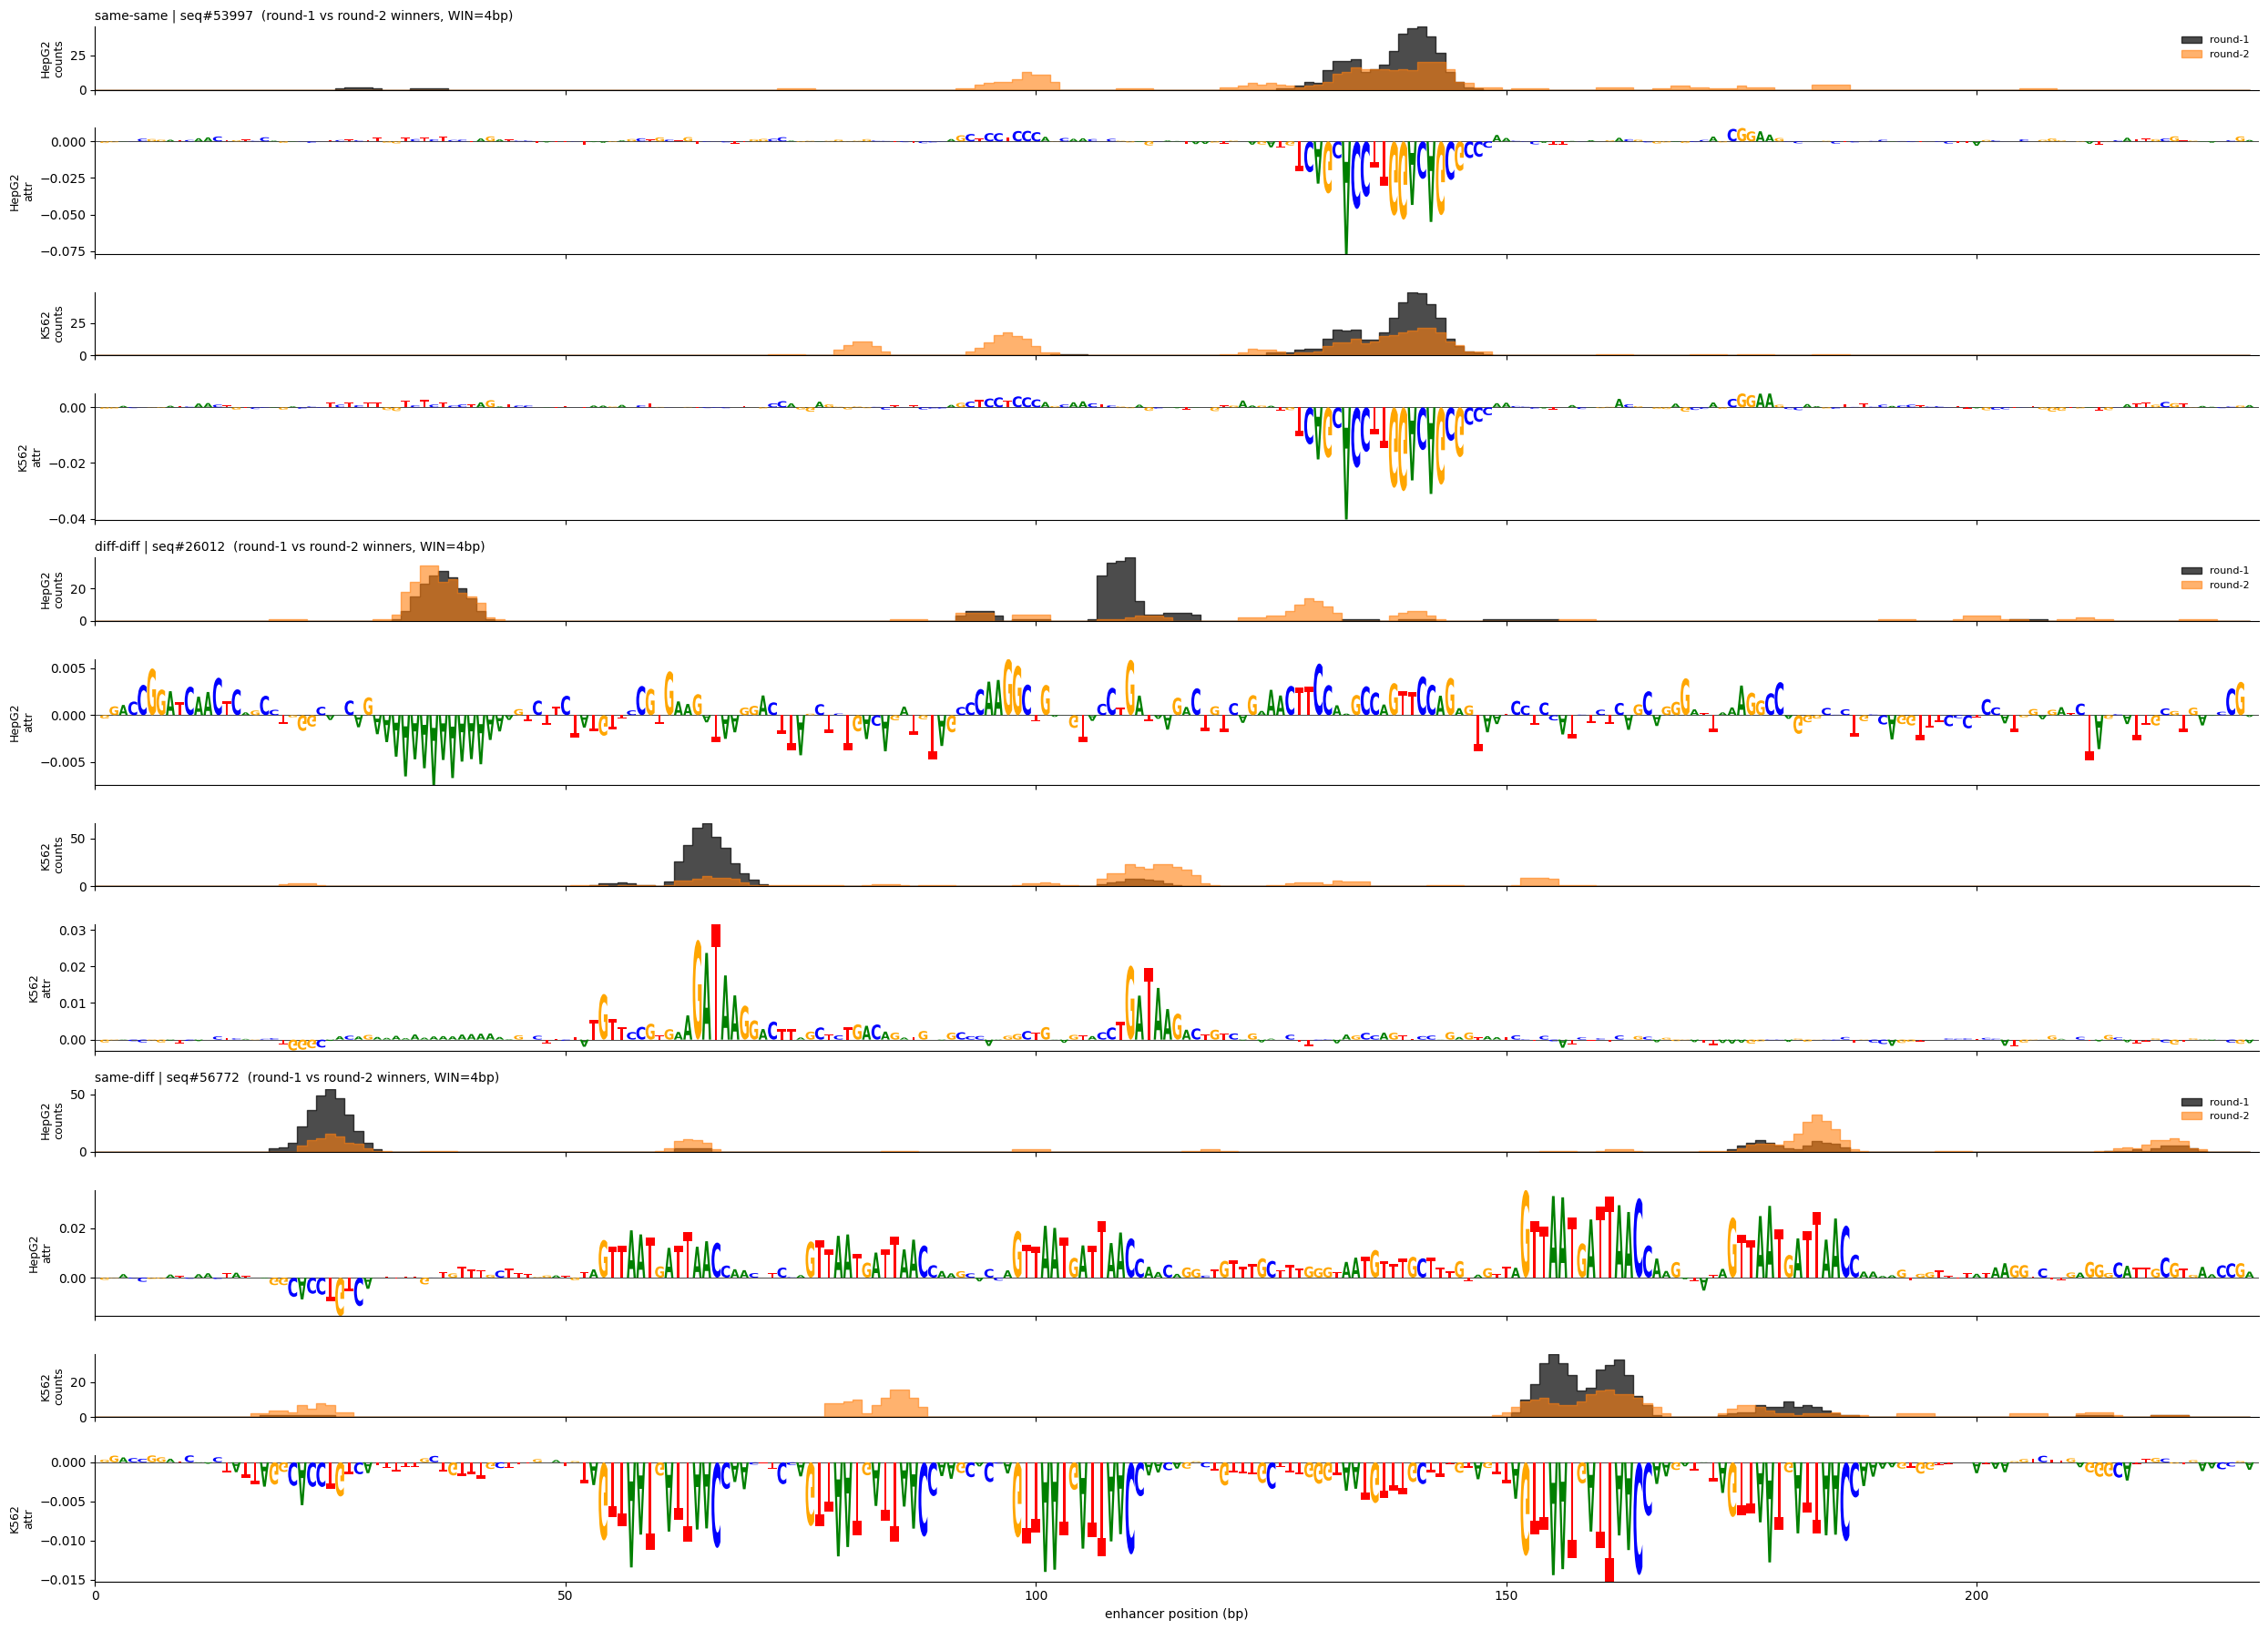

In [12]:
# viz: same layout as round-1 but overlay round-1 (dark) and round-2 (light) winners
R1_COLOR = '#000000'   # round-1 = black
R2_COLOR = '#ff7f0e'   # round-2 = orange

n_seqs   = len(groups)
ROWS_PER = 4
xs = np.arange(ENH_LEN)

fig, axes = plt.subplots(ROWS_PER * n_seqs, 1,
                         figsize=(25, 3 * ROWS_PER * n_seqs / 2),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1, 2, 1, 2] * n_seqs})

for gi, (name, idx) in enumerate(groups):
    base = gi * ROWS_PER
    for ci, ct in enumerate(CTS):
        ax_d = axes[base + 2*ci]
        ax_l = axes[base + 2*ci + 1]

        d1 = coverage_counts(winners[name][ct],  WIN, ENH_LEN)
        d2 = coverage_counts(winners2[name][ct], WIN, ENH_LEN)
        ax_d.fill_between(xs, d1, 0, color=R1_COLOR, alpha=0.7, step='mid', label='round-1')
        ax_d.fill_between(xs, d2, 0, color=R2_COLOR, alpha=0.6, step='mid', label='round-2')
        ymax = max(int(d1.max()), int(d2.max()), 1)
        ax_d.set_ylim(0, ymax)
        ax_d.set_ylabel(f'{ct}\ncounts', fontsize=9)
        if ci == 0:
            ax_d.set_title(f'{name} | seq#{idx}  (round-1 vs round-2 winners, WIN={WIN}bp)',
                           fontsize=10, loc='left')
            ax_d.legend(loc='upper right', fontsize=8, frameon=False)
        for sp in ('top', 'right'): ax_d.spines[sp].set_visible(False)

        att = em.attr[ct][idx, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax_l)
        ax_l.set_ylabel(f'{ct}\nattr', fontsize=9)
        for sp in ('top', 'right'): ax_l.spines[sp].set_visible(False)

axes[-1].set_xlabel('enhancer position (bp)')
axes[-1].set_xlim(0, ENH_LEN)
plt.tight_layout(); plt.show()


same-same HepG2: WT=-1.259  KO mean=-0.244  (n=100)
same-same K562: WT=-0.526  KO mean=0.119  (n=100)
diff-diff HepG2: WT=-0.963  KO mean=-0.876  (n=100)
diff-diff K562: WT=0.237  KO mean=-0.489  (n=100)
same-diff HepG2: WT=1.836  KO mean=1.891  (n=100)
same-diff K562: WT=-0.983  KO mean=-1.053  (n=100)


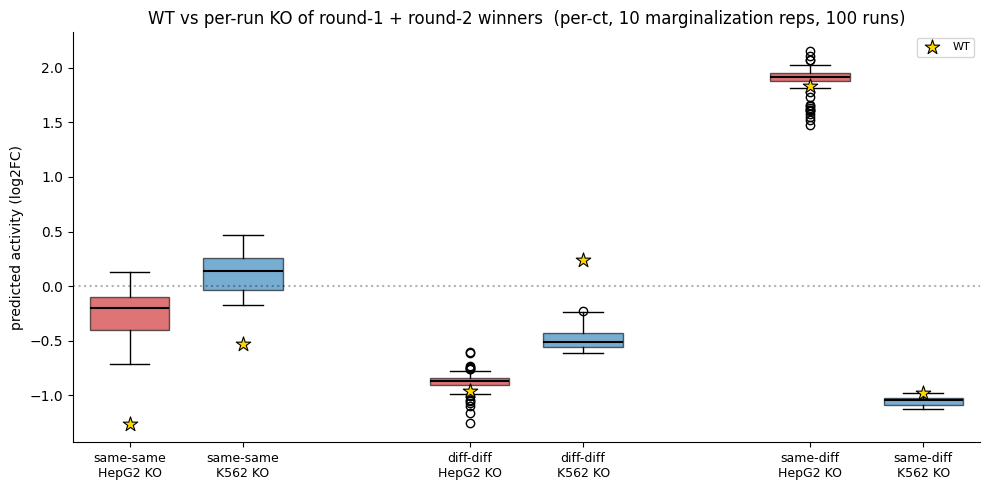

In [19]:
# per-run KO of (round-1 winner + round-2 winner), per-ct, marginalized
# y = activity. Per (seq, ct): one WT value + 100 KO values (one per run).

N_REPS_KO = 10   # dinuc-shuffle reps per run (marginalization)

wt_acts = {ct: {} for ct in CTS}
ko_acts = {ct: {name: [] for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        wt_acts[ct][name] = float(em._predict_tensor(wt, models=models, batch_size=4)[ct][0])
        w1s = winners[name][ct]
        w2s = winners2[name][ct]
        for run_i, (w1, w2) in enumerate(zip(w1s, w2s)):
            w1, w2 = int(w1), int(w2)
            shuf = dinuc_shuf(wt, n=N_REPS_KO,
                              random_state=int(idx)*9999 + run_i)[0]
            chim = wt.expand(N_REPS_KO, -1, -1).clone()
            chim[:, :, w1:w1+WIN] = shuf[:, :, w1:w1+WIN]
            chim[:, :, w2:w2+WIN] = shuf[:, :, w2:w2+WIN]
            p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
            ko_acts[ct][name].append(float(p.mean()))   # marginalized
        ko_acts[ct][name] = np.array(ko_acts[ct][name])
        print(f'{name} {ct}: WT={wt_acts[ct][name]:.3f}  '
              f'KO mean={ko_acts[ct][name].mean():.3f}  (n={len(ko_acts[ct][name])})')

# plot: 3 seqs x 2 ct = 6 KO boxes, WT shown as gold star
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}

fig, ax = plt.subplots(figsize=(10, 5))
data, xpos, labels, colors, wts = [], [], [], [], []
for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        data.append(ko_acts[ct][name])
        xpos.append(i*3 + j)
        labels.append(f'{name}\n{ct} KO')
        colors.append(ct_color[ct])
        wts.append(wt_acts[ct][name])

bp = ax.boxplot(data, positions=xpos, widths=0.7, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)

for x, w in zip(xpos, wts):
    ax.scatter([x], [w], marker='*', s=120, color='gold', edgecolors='black',
               linewidth=0.8, zorder=5, label='WT' if x == xpos[0] else None)

ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_xticks(xpos); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs per-run KO of round-1 + round-2 winners  '
             f'(per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')
ax.legend(loc='best', fontsize=8)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


In [16]:
# round-3 screen: each (round-1 + round-2) winner pair seeds its OWN run (paired, per-ct)
winners3 = {name: {ct: [] for ct in CTS} for name, _ in groups}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i, (w1, w2) in enumerate(zip(winners[name][ct], winners2[name][ct])):
            w1, w2 = int(w1), int(w2)
            # KO both prior winners -> per-run starting seq
            wt_ko = wt.clone()
            ko_shuf = dinuc_shuf(wt, n=1, random_state=int(idx)*777 + run_i*13 + w1 + w2)[0]
            wt_ko[:, :, w1:w1+WIN] = ko_shuf[:, :, w1:w1+WIN]
            wt_ko[:, :, w2:w2+WIN] = ko_shuf[:, :, w2:w2+WIN]
            wt_p = float(em._predict_tensor(wt_ko, models=models, batch_size=4)[ct][0])

            # forward screen on top of wt_ko
            starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_TRY)
            chunks = []
            for s in starts:
                shuf = dinuc_shuf(wt_ko, n=N_REPS,
                                  random_state=int(idx)*1_000_000 + run_i*1000 + int(s))[0]
                chim = wt_ko.expand(N_REPS, -1, -1).clone()
                chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
                chunks.append(chim)
            all_chim = torch.cat(chunks, dim=0)
            p = em._predict_tensor(all_chim, models=models, batch_size=128)[ct]
            pm = p.reshape(N_TRY, N_REPS).mean(axis=1)
            impact = np.abs(pm - wt_p)
            winners3[name][ct].append(int(starts[int(impact.argmax())]))
        winners3[name][ct] = np.array(winners3[name][ct])
        print(f'{name} {ct}: r3 winners = {winners3[name][ct].tolist()}')


same-same HepG2: r3 winners = [93, 182, 135, 183, 98, 133, 146, 130, 95, 127, 183, 174, 189, 95, 124, 132, 99, 142, 137, 128, 132, 91, 123, 132, 121, 183, 99, 132, 95, 92, 99, 151, 133, 132, 136, 132, 92, 127, 137, 183, 142, 128, 160, 91, 132, 141, 133, 175, 96, 92, 136, 165, 99, 124, 98, 124, 170, 139, 90, 143, 96, 123, 146, 182, 96, 90, 160, 90, 99, 123, 124, 99, 171, 92, 172, 139, 136, 95, 99, 183, 98, 94, 99, 98, 183, 95, 123, 171, 96, 120, 123, 131, 95, 129, 180, 92, 136, 124, 97, 99]
same-same K562: r3 winners = [217, 98, 93, 95, 72, 80, 94, 76, 79, 79, 79, 128, 140, 97, 95, 96, 80, 94, 133, 123, 131, 120, 97, 81, 124, 96, 96, 81, 79, 72, 80, 79, 123, 78, 120, 91, 123, 150, 71, 80, 72, 79, 183, 78, 160, 79, 137, 175, 146, 79, 132, 128, 123, 98, 78, 120, 145, 95, 97, 77, 81, 124, 152, 79, 79, 132, 97, 77, 98, 72, 79, 163, 95, 82, 79, 183, 141, 75, 129, 71, 80, 135, 109, 72, 81, 79, 123, 120, 77, 94, 79, 95, 72, 96, 72, 132, 78, 140, 161, 96]
diff-diff HepG2: r3 winners = [3, 59, 2

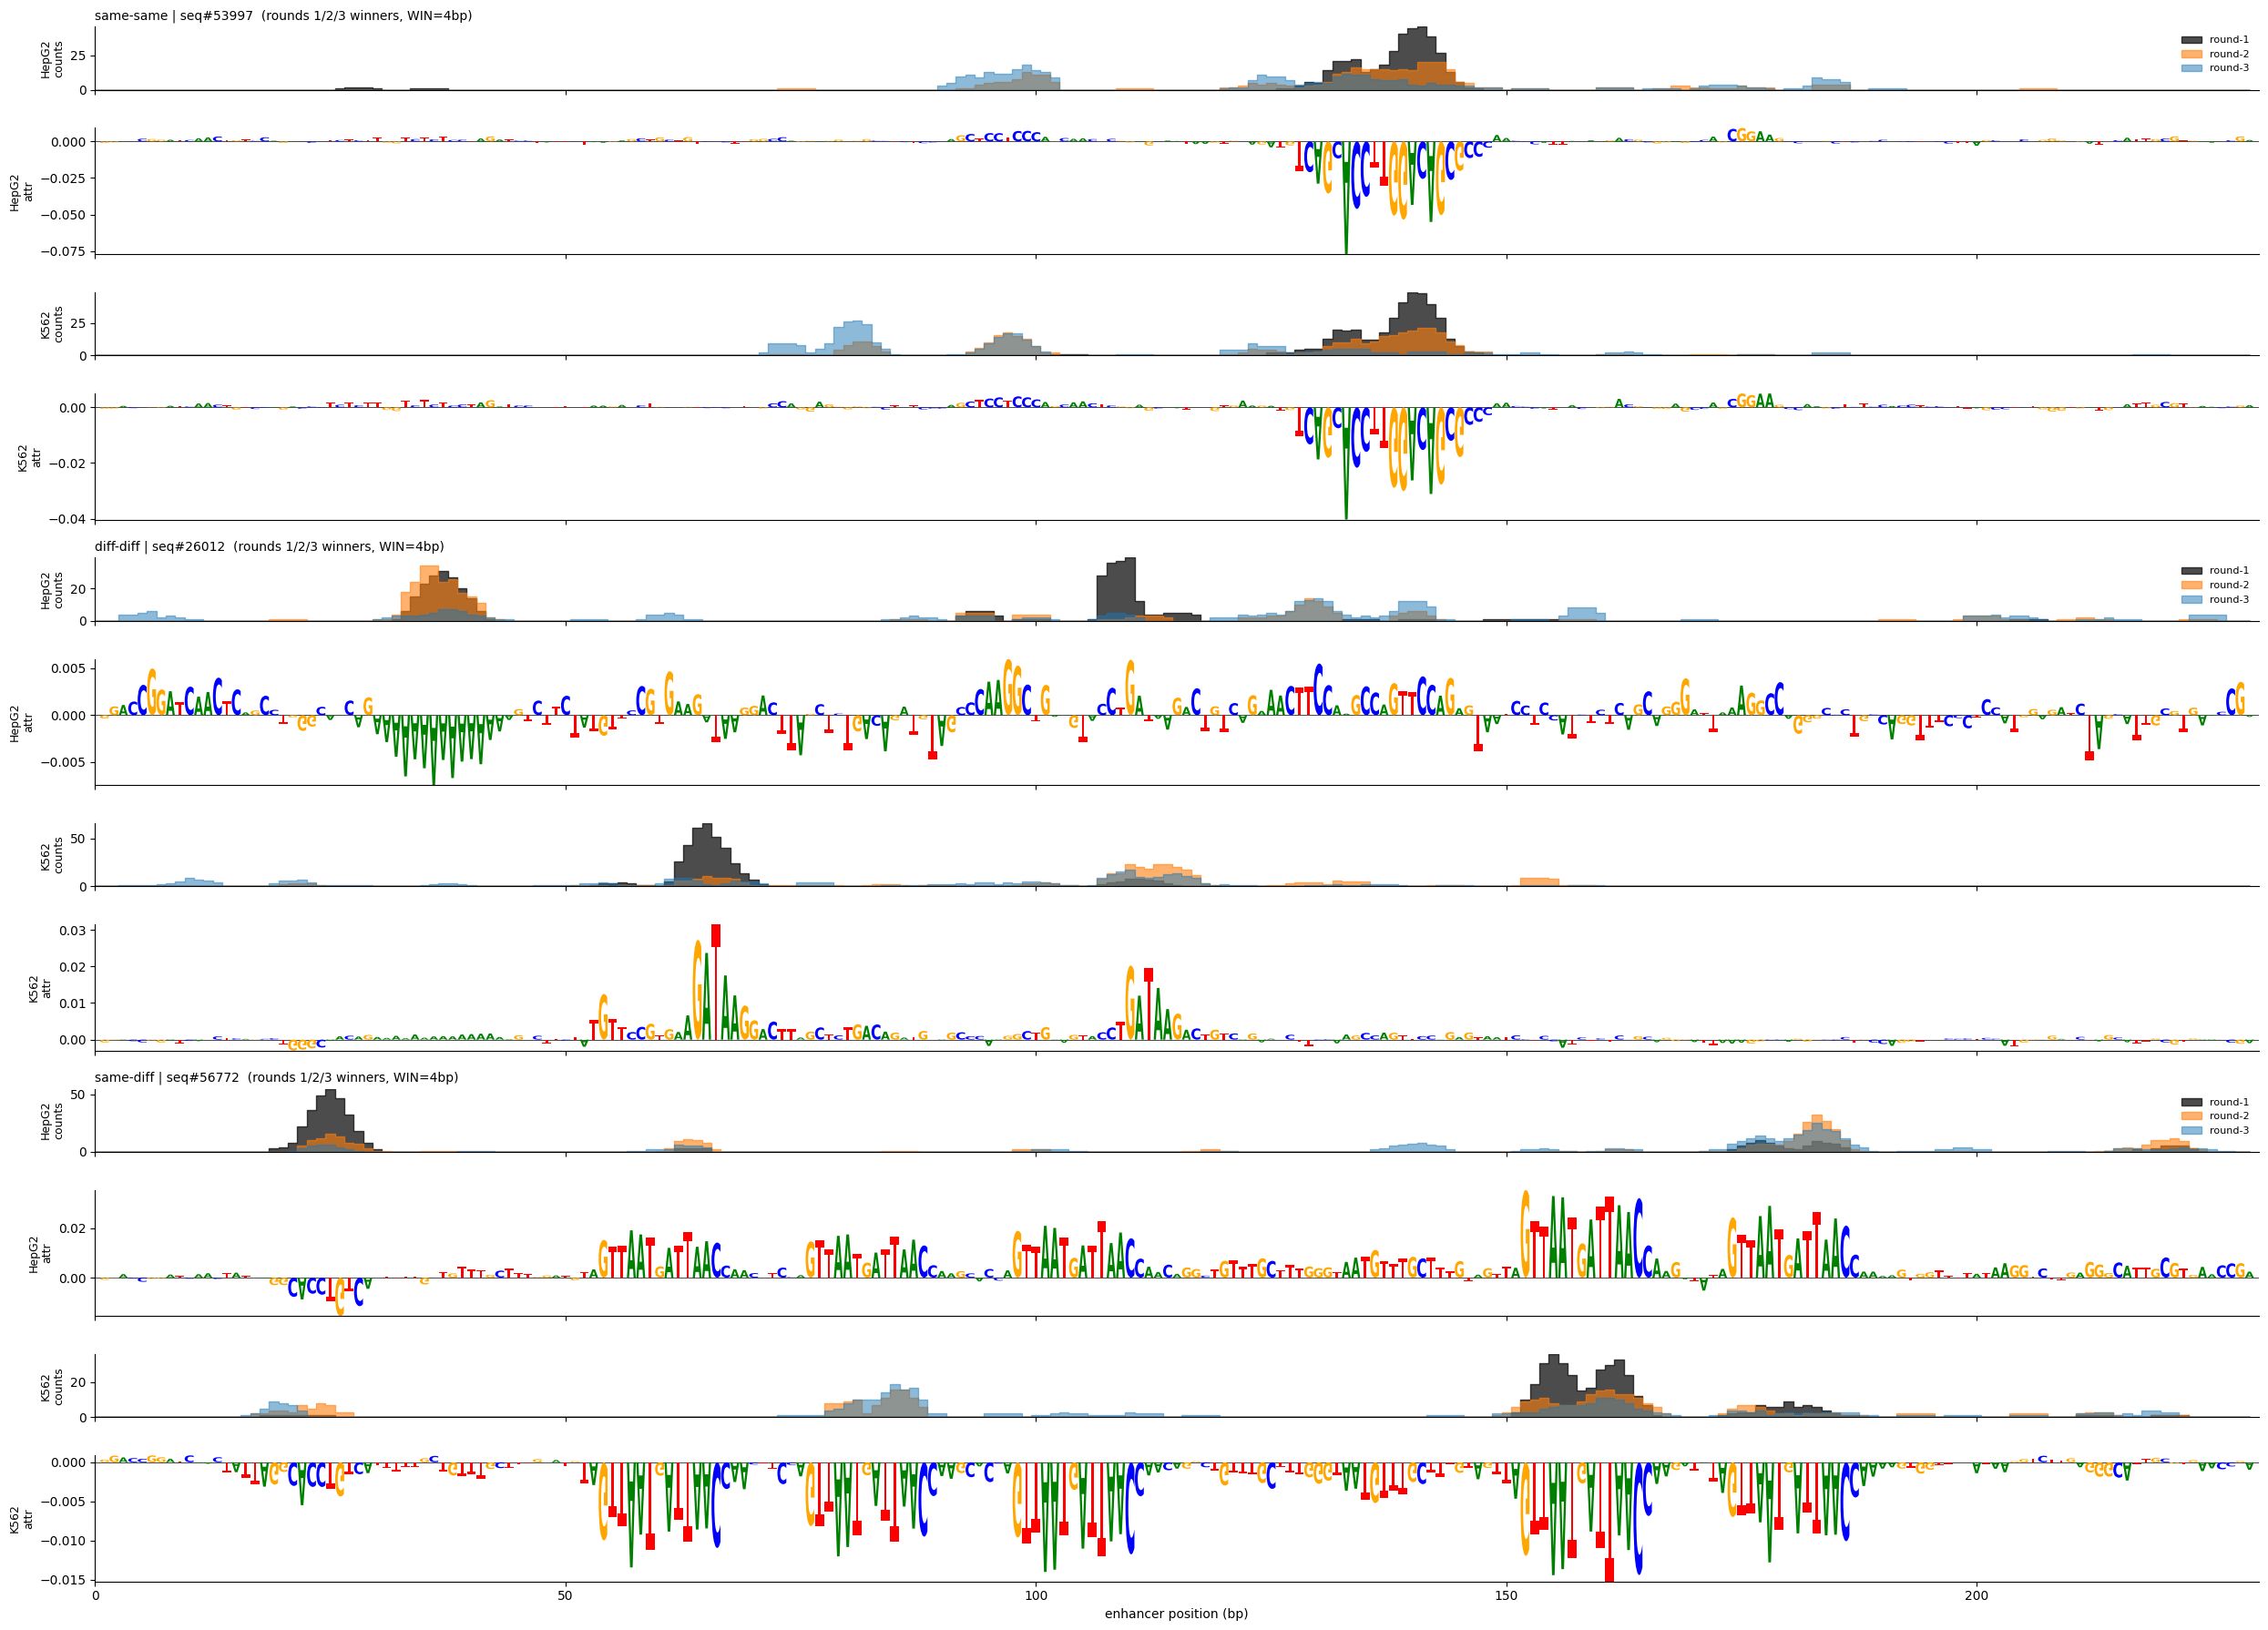

In [17]:
# viz: counts overlay of round-1 / round-2 / round-3 winners + attribution logo
R1_COLOR = '#000000'
R2_COLOR = '#ff7f0e'
R3_COLOR = '#1f77b4'

n_seqs   = len(groups)
ROWS_PER = 4
xs = np.arange(ENH_LEN)

fig, axes = plt.subplots(ROWS_PER * n_seqs, 1,
                         figsize=(25, 3 * ROWS_PER * n_seqs / 2),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1, 2, 1, 2] * n_seqs})

for gi, (name, idx) in enumerate(groups):
    base = gi * ROWS_PER
    for ci, ct in enumerate(CTS):
        ax_d = axes[base + 2*ci]
        ax_l = axes[base + 2*ci + 1]

        d1 = coverage_counts(winners[name][ct],  WIN, ENH_LEN)
        d2 = coverage_counts(winners2[name][ct], WIN, ENH_LEN)
        d3 = coverage_counts(winners3[name][ct], WIN, ENH_LEN)
        ax_d.fill_between(xs, d1, 0, color=R1_COLOR, alpha=0.7, step='mid', label='round-1')
        ax_d.fill_between(xs, d2, 0, color=R2_COLOR, alpha=0.6, step='mid', label='round-2')
        ax_d.fill_between(xs, d3, 0, color=R3_COLOR, alpha=0.5, step='mid', label='round-3')
        ymax = max(int(d1.max()), int(d2.max()), int(d3.max()), 1)
        ax_d.set_ylim(0, ymax)
        ax_d.set_ylabel(f'{ct}\ncounts', fontsize=9)
        if ci == 0:
            ax_d.set_title(f'{name} | seq#{idx}  (rounds 1/2/3 winners, WIN={WIN}bp)',
                           fontsize=10, loc='left')
            ax_d.legend(loc='upper right', fontsize=8, frameon=False)
        for sp in ('top', 'right'): ax_d.spines[sp].set_visible(False)

        att = em.attr[ct][idx, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax_l)
        ax_l.set_ylabel(f'{ct}\nattr', fontsize=9)
        for sp in ('top', 'right'): ax_l.spines[sp].set_visible(False)

axes[-1].set_xlabel('enhancer position (bp)')
axes[-1].set_xlim(0, ENH_LEN)
plt.tight_layout(); plt.show()


same-same HepG2: WT=-1.26  r1=-0.38  r2=-0.76  r3=-1.03  all=-0.25
same-same K562: WT=-0.53  r1=0.07  r2=-0.21  r3=-0.46  all=0.01
diff-diff HepG2: WT=-0.96  r1=-0.98  r2=-0.90  r3=-0.98  all=-0.89
diff-diff K562: WT=0.24  r1=-0.40  r2=-0.08  r3=0.02  all=-0.52
same-diff HepG2: WT=1.84  r1=1.93  r2=1.80  r3=1.79  all=1.83
same-diff K562: WT=-0.98  r1=-1.06  r2=-1.01  r3=-1.00  all=-1.03


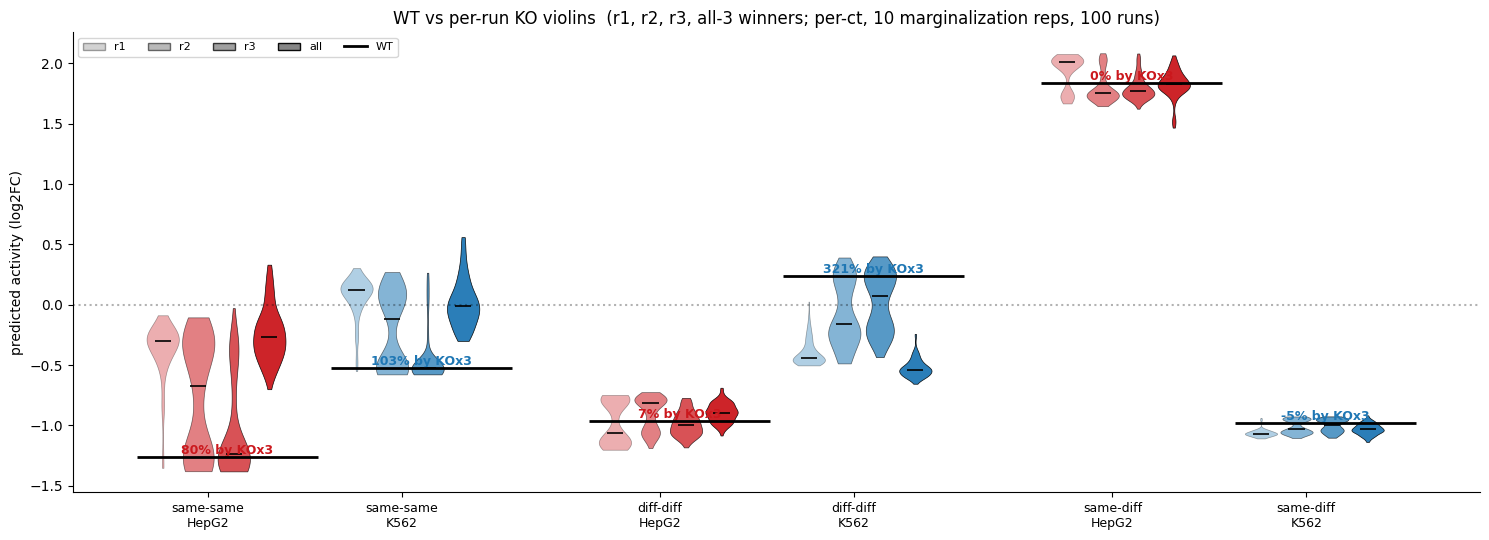

In [21]:
# round-3 viz: per (seq, ct) bucket -> WT line + 4 violins (r1, r2, r3, all-3)
# each violin = 100 per-run marginalized KO activities (N_REPS_KO shuffles each)

ko_each = {ct: {name: {'r1': [], 'r2': [], 'r3': [], 'all': []}
                for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i in range(N_RUNS):
            w1 = int(winners [name][ct][run_i])
            w2 = int(winners2[name][ct][run_i])
            w3 = int(winners3[name][ct][run_i])
            shuf = dinuc_shuf(wt, n=N_REPS_KO,
                              random_state=int(idx)*9999 + run_i)[0]
            base = wt.expand(N_REPS_KO, -1, -1)
            for tag, wins in [('r1', [w1]), ('r2', [w2]), ('r3', [w3]),
                              ('all', [w1, w2, w3])]:
                chim = base.clone()
                for w in wins:
                    chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
                p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
                ko_each[ct][name][tag].append(float(p.mean()))
        for tag in ('r1', 'r2', 'r3', 'all'):
            ko_each[ct][name][tag] = np.array(ko_each[ct][name][tag])
        print(f'{name} {ct}: WT={wt_acts[ct][name]:.2f}  '
              f"r1={ko_each[ct][name]['r1'].mean():.2f}  "
              f"r2={ko_each[ct][name]['r2'].mean():.2f}  "
              f"r3={ko_each[ct][name]['r3'].mean():.2f}  "
              f"all={ko_each[ct][name]['all'].mean():.2f}")

# --- plot ---
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}
tags = ['r1', 'r2', 'r3', 'all']
tag_alpha = {'r1': 0.35, 'r2': 0.55, 'r3': 0.75, 'all': 0.95}

fig, ax = plt.subplots(figsize=(15, 5.5))
xticks_main, xlabels_main = [], []
BUCKET_W = 3.0
GAP = 1.0

for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        xticks_main.append(center + 0.7)
        xlabels_main.append(f'{name}\n{ct}')

        wt_v = wt_acts[ct][name]
        ko_all_mean = ko_each[ct][name]['all'].mean()
        pct = 100.0 * (wt_v - ko_all_mean) / wt_v if wt_v != 0 else float('nan')

        # WT horizontal line spanning bucket
        ax.hlines(wt_v, center - 0.4, center + 2.4, color='black',
                  linewidth=2, zorder=6)

        # 4 violins
        for k, tag in enumerate(tags):
            x = center + k*0.55
            v = ax.violinplot([ko_each[ct][name][tag]], positions=[x],
                              widths=0.5, showmeans=False, showmedians=True,
                              showextrema=False)
            for body in v['bodies']:
                body.set_facecolor(ct_color[ct])
                body.set_alpha(tag_alpha[tag])
                body.set_edgecolor('black'); body.set_linewidth(0.5)
            v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.2)

        # % explained by triple KO, above bucket
        ax.text(center + 1.0, wt_v, f'{pct:.0f}% by KOx3',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=ct_color[ct])

ax.set_xticks(xticks_main); ax.set_xticklabels(xlabels_main, fontsize=9)
ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs per-run KO violins  (r1, r2, r3, all-3 winners; '
             f'per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')

from matplotlib.patches import Patch
handles = [Patch(facecolor='gray', alpha=tag_alpha[t], edgecolor='black', label=t)
           for t in tags]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2, label='WT'))
ax.legend(handles=handles, loc='best', fontsize=8, ncol=5)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


same-same HepG2: WT=-1.26  r1=-0.38  r1+2=-0.24  r1+2+3=-0.25
same-same K562: WT=-0.53  r1=0.07  r1+2=0.12  r1+2+3=0.01
diff-diff HepG2: WT=-0.96  r1=-0.98  r1+2=-0.88  r1+2+3=-0.89
diff-diff K562: WT=0.24  r1=-0.40  r1+2=-0.49  r1+2+3=-0.52
same-diff HepG2: WT=1.84  r1=1.93  r1+2=1.89  r1+2+3=1.83
same-diff K562: WT=-0.98  r1=-1.06  r1+2=-1.05  r1+2+3=-1.03


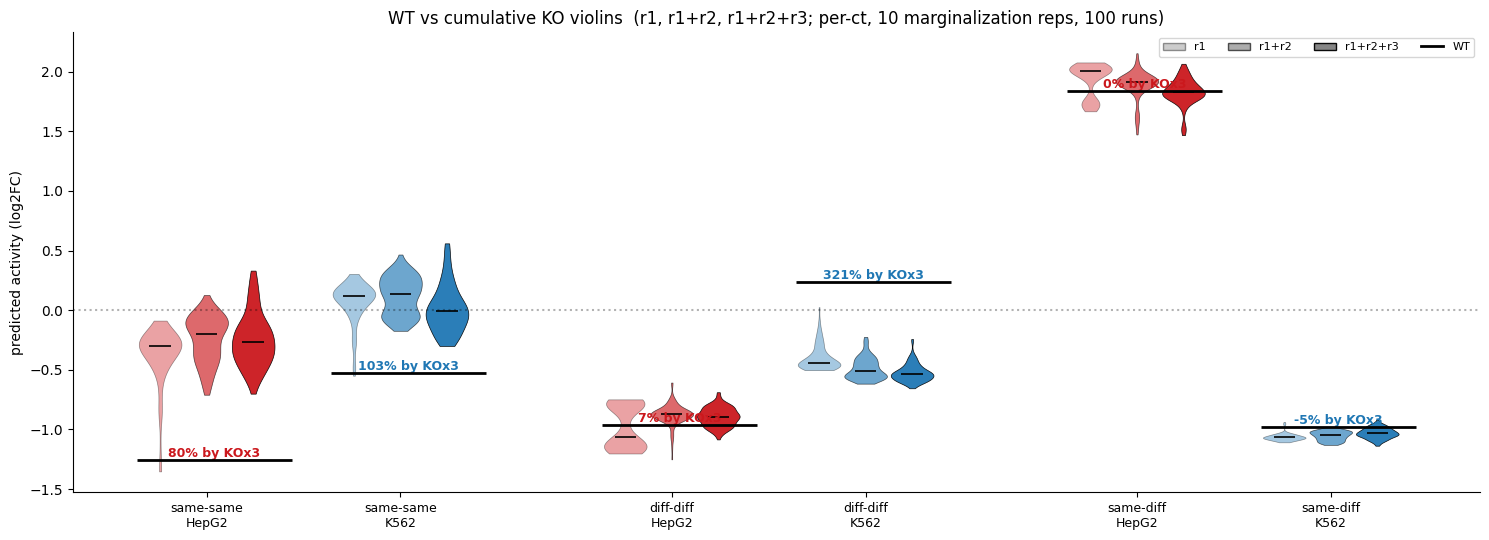

In [22]:
# cumulative KO viz: per (seq, ct) -> WT line + 3 violins (r1, r1+r2, r1+r2+r3)
ko_cum = {ct: {name: {'r1': [], 'r12': [], 'r123': []}
               for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i in range(N_RUNS):
            w1 = int(winners [name][ct][run_i])
            w2 = int(winners2[name][ct][run_i])
            w3 = int(winners3[name][ct][run_i])
            shuf = dinuc_shuf(wt, n=N_REPS_KO,
                              random_state=int(idx)*9999 + run_i)[0]
            base = wt.expand(N_REPS_KO, -1, -1)
            for tag, wins in [('r1',   [w1]),
                              ('r12',  [w1, w2]),
                              ('r123', [w1, w2, w3])]:
                chim = base.clone()
                for w in wins:
                    chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
                p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
                ko_cum[ct][name][tag].append(float(p.mean()))
        for tag in ('r1', 'r12', 'r123'):
            ko_cum[ct][name][tag] = np.array(ko_cum[ct][name][tag])
        print(f'{name} {ct}: WT={wt_acts[ct][name]:.2f}  '
              f"r1={ko_cum[ct][name]['r1'].mean():.2f}  "
              f"r1+2={ko_cum[ct][name]['r12'].mean():.2f}  "
              f"r1+2+3={ko_cum[ct][name]['r123'].mean():.2f}")

# --- plot ---
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}
tags = ['r1', 'r12', 'r123']
tag_alpha = {'r1': 0.4, 'r12': 0.65, 'r123': 0.95}
tag_label = {'r1': 'r1', 'r12': 'r1+r2', 'r123': 'r1+r2+r3'}

fig, ax = plt.subplots(figsize=(15, 5.5))
xticks_main, xlabels_main = [], []
BUCKET_W = 2.5
GAP = 1.0

for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        xticks_main.append(center + 0.6)
        xlabels_main.append(f'{name}\n{ct}')

        wt_v = wt_acts[ct][name]
        ko123_mean = ko_cum[ct][name]['r123'].mean()
        pct = 100.0 * (wt_v - ko123_mean) / wt_v if wt_v != 0 else float('nan')

        ax.hlines(wt_v, center - 0.3, center + 1.7, color='black',
                  linewidth=2, zorder=6)

        for k, tag in enumerate(tags):
            x = center + k*0.6
            v = ax.violinplot([ko_cum[ct][name][tag]], positions=[x],
                              widths=0.55, showmeans=False, showmedians=True,
                              showextrema=False)
            for body in v['bodies']:
                body.set_facecolor(ct_color[ct])
                body.set_alpha(tag_alpha[tag])
                body.set_edgecolor('black'); body.set_linewidth(0.5)
            v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.2)

        ax.text(center + 0.7, wt_v, f'{pct:.0f}% by KOx3',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=ct_color[ct])

ax.set_xticks(xticks_main); ax.set_xticklabels(xlabels_main, fontsize=9)
ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs cumulative KO violins  (r1, r1+r2, r1+r2+r3; '
             f'per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')

from matplotlib.patches import Patch
handles = [Patch(facecolor='gray', alpha=tag_alpha[t], edgecolor='black',
                 label=tag_label[t]) for t in tags]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2, label='WT'))
ax.legend(handles=handles, loc='best', fontsize=8, ncol=4)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()


In [24]:
# round-4 screen: each (r1+r2+r3) winner triple seeds its OWN run (paired, per-ct)
winners4 = {name: {ct: [] for ct in CTS} for name, _ in groups}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i, (w1, w2, w3) in enumerate(zip(winners[name][ct],
                                                  winners2[name][ct],
                                                  winners3[name][ct])):
            w1, w2, w3 = int(w1), int(w2), int(w3)
            wt_ko = wt.clone()
            ko_shuf = dinuc_shuf(wt, n=1,
                                 random_state=int(idx)*555 + run_i*17 + w1 + w2 + w3)[0]
            for w in (w1, w2, w3):
                wt_ko[:, :, w:w+WIN] = ko_shuf[:, :, w:w+WIN]
            wt_p = float(em._predict_tensor(wt_ko, models=models, batch_size=4)[ct][0])

            starts = rng.integers(0, ENH_LEN - WIN + 1, size=N_TRY)
            chunks = []
            for s in starts:
                shuf = dinuc_shuf(wt_ko, n=N_REPS,
                                  random_state=int(idx)*1_000_000 + run_i*1000 + int(s))[0]
                chim = wt_ko.expand(N_REPS, -1, -1).clone()
                chim[:, :, s:s+WIN] = shuf[:, :, s:s+WIN]
                chunks.append(chim)
            all_chim = torch.cat(chunks, dim=0)
            p = em._predict_tensor(all_chim, models=models, batch_size=128)[ct]
            pm = p.reshape(N_TRY, N_REPS).mean(axis=1)
            impact = np.abs(pm - wt_p)
            winners4[name][ct].append(int(starts[int(impact.argmax())]))
        winners4[name][ct] = np.array(winners4[name][ct])
        print(f'{name} {ct}: r4 winners = {winners4[name][ct].tolist()}')


same-same HepG2: r4 winners = [72, 141, 91, 186, 172, 90, 175, 124, 167, 119, 138, 121, 96, 124, 183, 120, 172, 138, 127, 98, 183, 135, 98, 124, 144, 131, 136, 123, 183, 132, 181, 96, 141, 175, 123, 151, 176, 123, 99, 174, 138, 123, 134, 145, 151, 144, 130, 157, 140, 81, 92, 177, 151, 96, 172, 97, 152, 91, 183, 98, 182, 92, 99, 132, 183, 122, 141, 143, 80, 129, 140, 142, 141, 81, 123, 99, 148, 183, 128, 142, 183, 122, 182, 160, 124, 124, 93, 95, 205, 122, 132, 158, 72, 122, 120, 144, 100, 141, 166, 124]
same-same K562: r4 winners = [79, 141, 71, 76, 98, 174, 183, 94, 137, 160, 97, 141, 183, 80, 217, 120, 121, 123, 72, 77, 99, 79, 79, 96, 72, 70, 217, 137, 99, 120, 96, 107, 81, 160, 72, 217, 127, 77, 137, 181, 123, 183, 95, 162, 140, 205, 189, 143, 75, 160, 145, 79, 94, 79, 182, 74, 81, 160, 72, 96, 95, 95, 80, 183, 95, 119, 183, 183, 157, 132, 99, 140, 132, 96, 123, 140, 76, 217, 93, 128, 91, 123, 143, 132, 128, 97, 77, 138, 142, 123, 93, 76, 95, 128, 144, 72, 181, 79, 160, 79]
diff-di

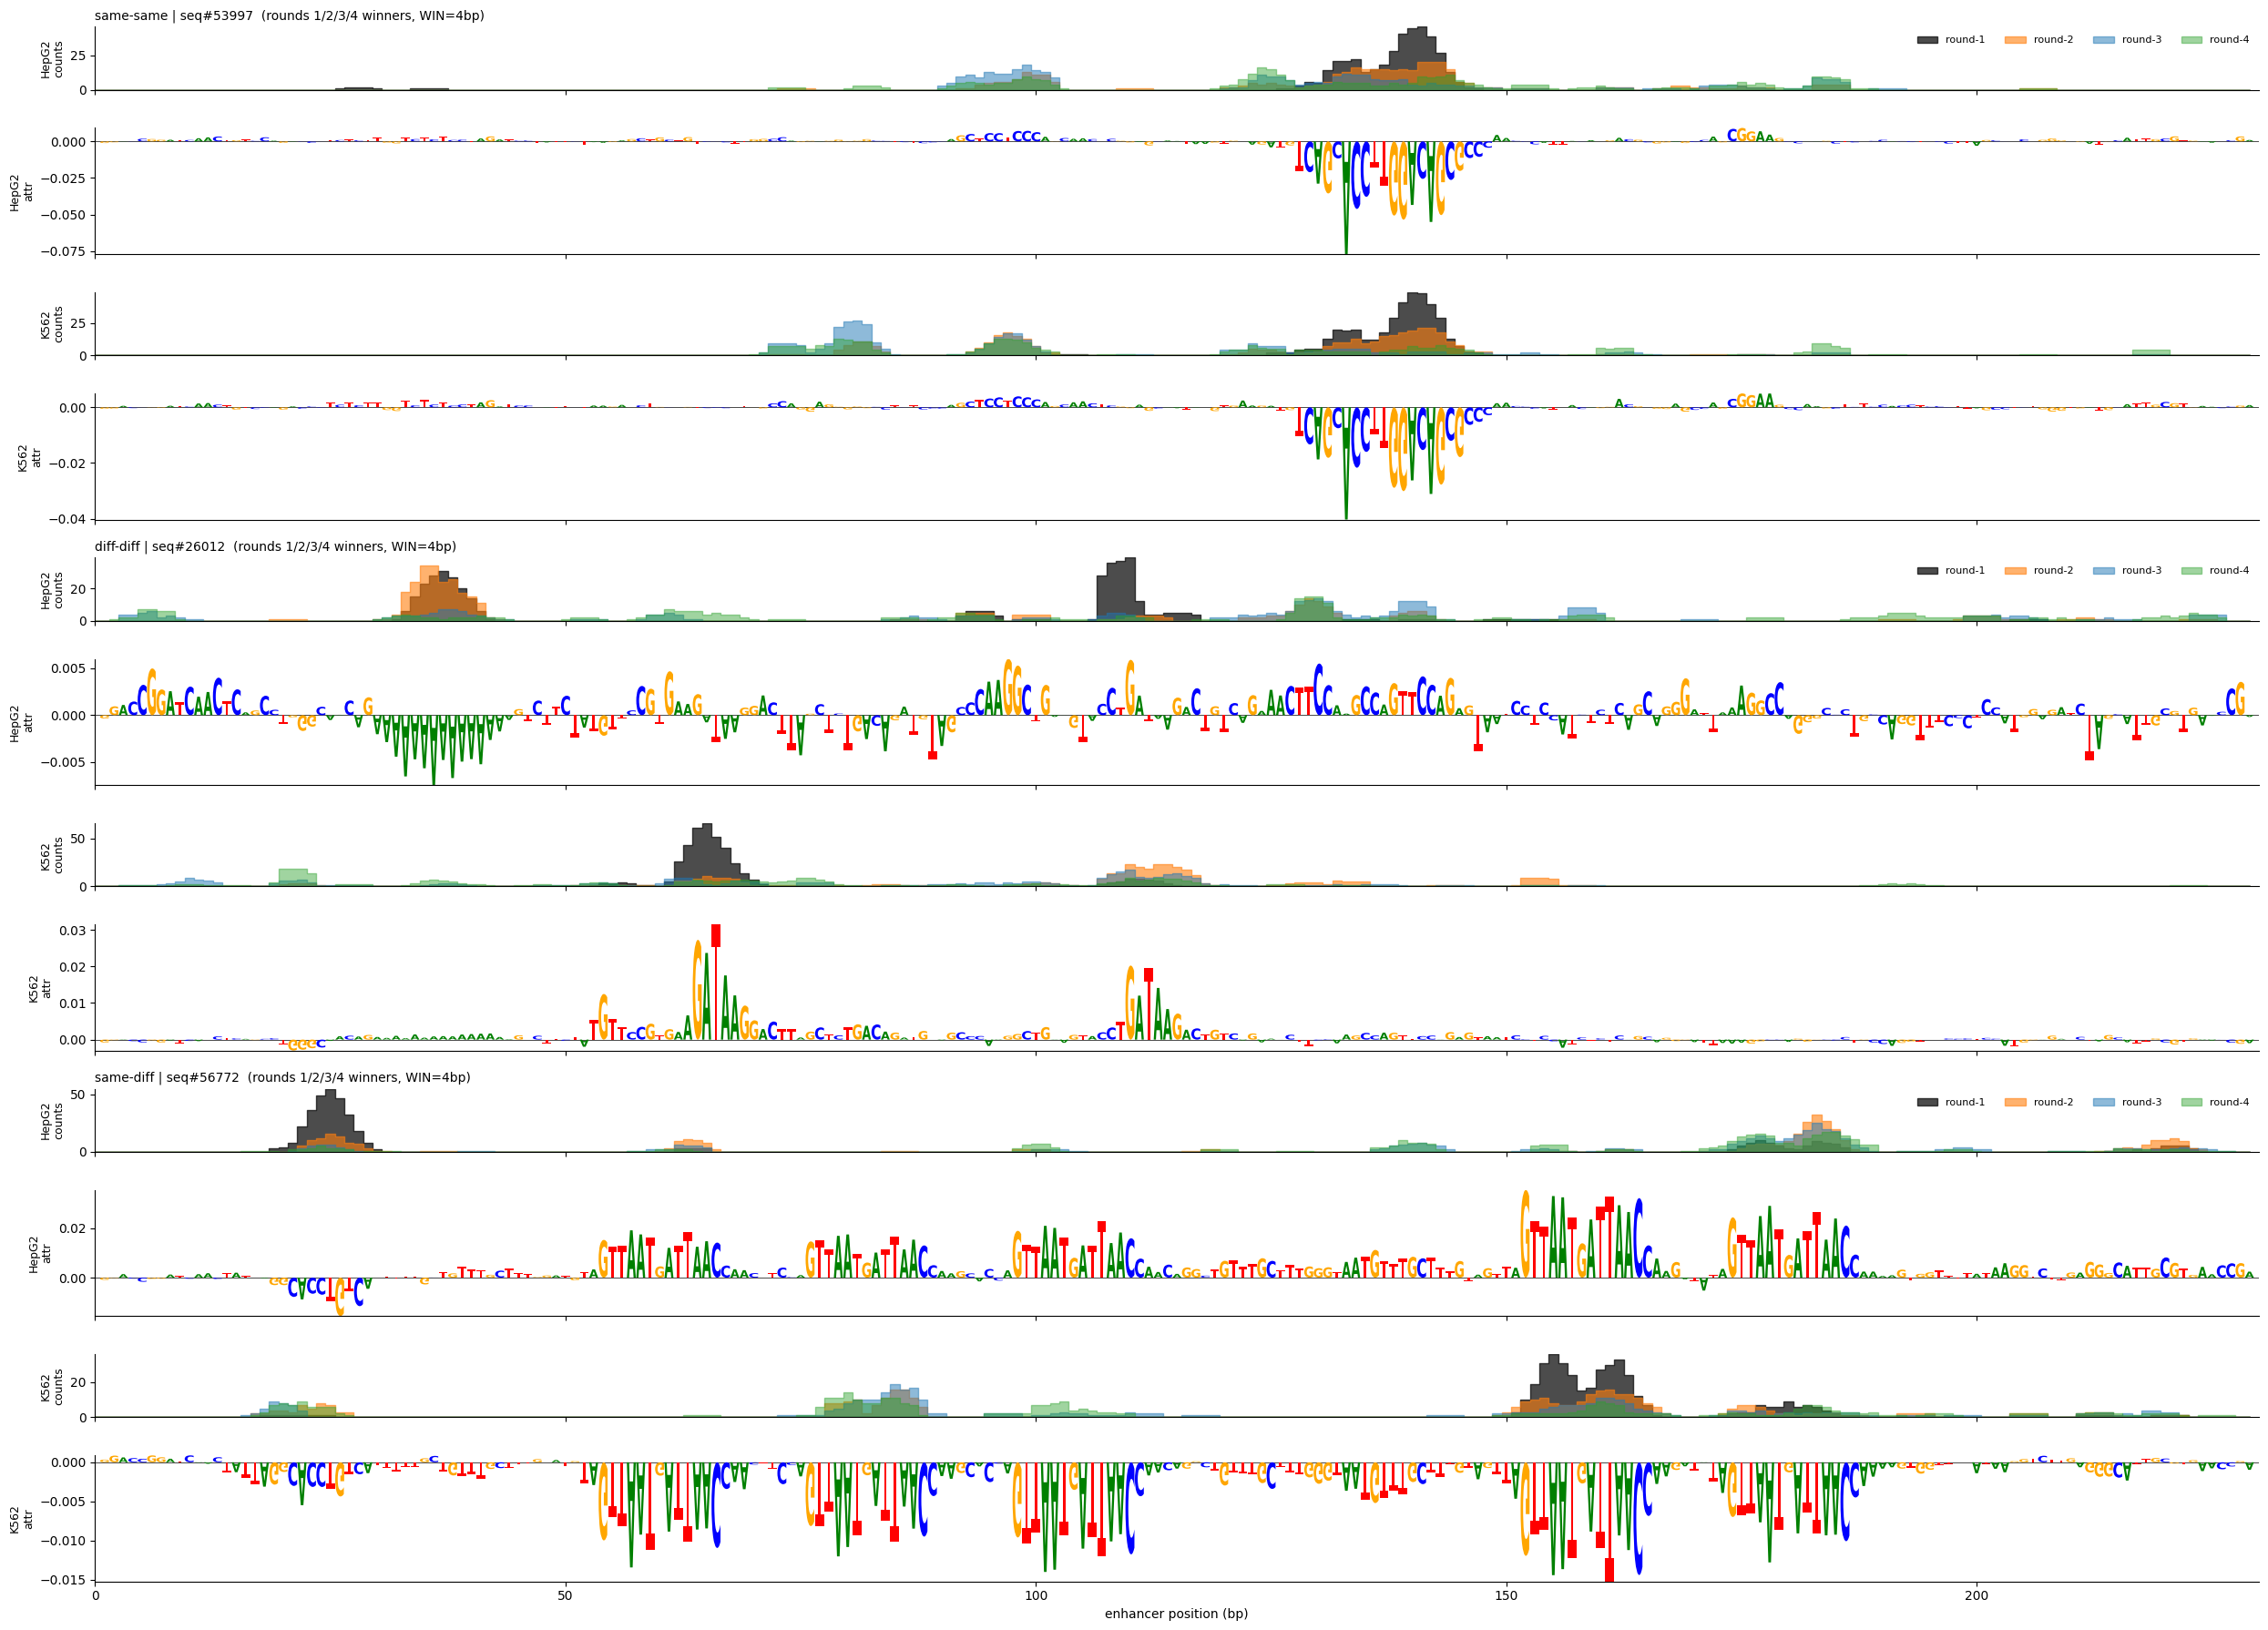

In [25]:
# viz: counts overlay of round-1 / 2 / 3 / 4 winners + attribution logo
R1_COLOR = '#000000'
R2_COLOR = '#ff7f0e'
R3_COLOR = '#1f77b4'
R4_COLOR = '#2ca02c'

n_seqs   = len(groups)
ROWS_PER = 4
xs = np.arange(ENH_LEN)

fig, axes = plt.subplots(ROWS_PER * n_seqs, 1,
                         figsize=(25, 3 * ROWS_PER * n_seqs / 2),
                         sharex=True,
                         gridspec_kw={'height_ratios': [1, 2, 1, 2] * n_seqs})

for gi, (name, idx) in enumerate(groups):
    base = gi * ROWS_PER
    for ci, ct in enumerate(CTS):
        ax_d = axes[base + 2*ci]
        ax_l = axes[base + 2*ci + 1]

        d1 = coverage_counts(winners [name][ct], WIN, ENH_LEN)
        d2 = coverage_counts(winners2[name][ct], WIN, ENH_LEN)
        d3 = coverage_counts(winners3[name][ct], WIN, ENH_LEN)
        d4 = coverage_counts(winners4[name][ct], WIN, ENH_LEN)
        ax_d.fill_between(xs, d1, 0, color=R1_COLOR, alpha=0.7, step='mid', label='round-1')
        ax_d.fill_between(xs, d2, 0, color=R2_COLOR, alpha=0.6, step='mid', label='round-2')
        ax_d.fill_between(xs, d3, 0, color=R3_COLOR, alpha=0.5, step='mid', label='round-3')
        ax_d.fill_between(xs, d4, 0, color=R4_COLOR, alpha=0.45, step='mid', label='round-4')
        ymax = max(int(d1.max()), int(d2.max()), int(d3.max()), int(d4.max()), 1)
        ax_d.set_ylim(0, ymax)
        ax_d.set_ylabel(f'{ct}\ncounts', fontsize=9)
        if ci == 0:
            ax_d.set_title(f'{name} | seq#{idx}  (rounds 1/2/3/4 winners, WIN={WIN}bp)',
                           fontsize=10, loc='left')
            ax_d.legend(loc='upper right', fontsize=8, frameon=False, ncol=4)
        for sp in ('top', 'right'): ax_d.spines[sp].set_visible(False)

        att = em.attr[ct][idx, :, :ENH_LEN].T
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=ax_l)
        ax_l.set_ylabel(f'{ct}\nattr', fontsize=9)
        for sp in ('top', 'right'): ax_l.spines[sp].set_visible(False)

axes[-1].set_xlabel('enhancer position (bp)')
axes[-1].set_xlim(0, ENH_LEN)
plt.tight_layout(); plt.show()


same-same HepG2: WT=-1.26  r1=-0.38  +r2=-0.24  +r3=-0.25  +r4=-0.23
same-same K562: WT=-0.53  r1=0.07  +r2=0.12  +r3=0.01  +r4=-0.06
diff-diff HepG2: WT=-0.96  r1=-0.98  +r2=-0.88  +r3=-0.89  +r4=-0.91
diff-diff K562: WT=0.24  r1=-0.40  +r2=-0.49  +r3=-0.52  +r4=-0.52
same-diff HepG2: WT=1.84  r1=1.93  +r2=1.89  +r3=1.83  +r4=1.76
same-diff K562: WT=-0.98  r1=-1.06  +r2=-1.05  +r3=-1.03  +r4=-1.00


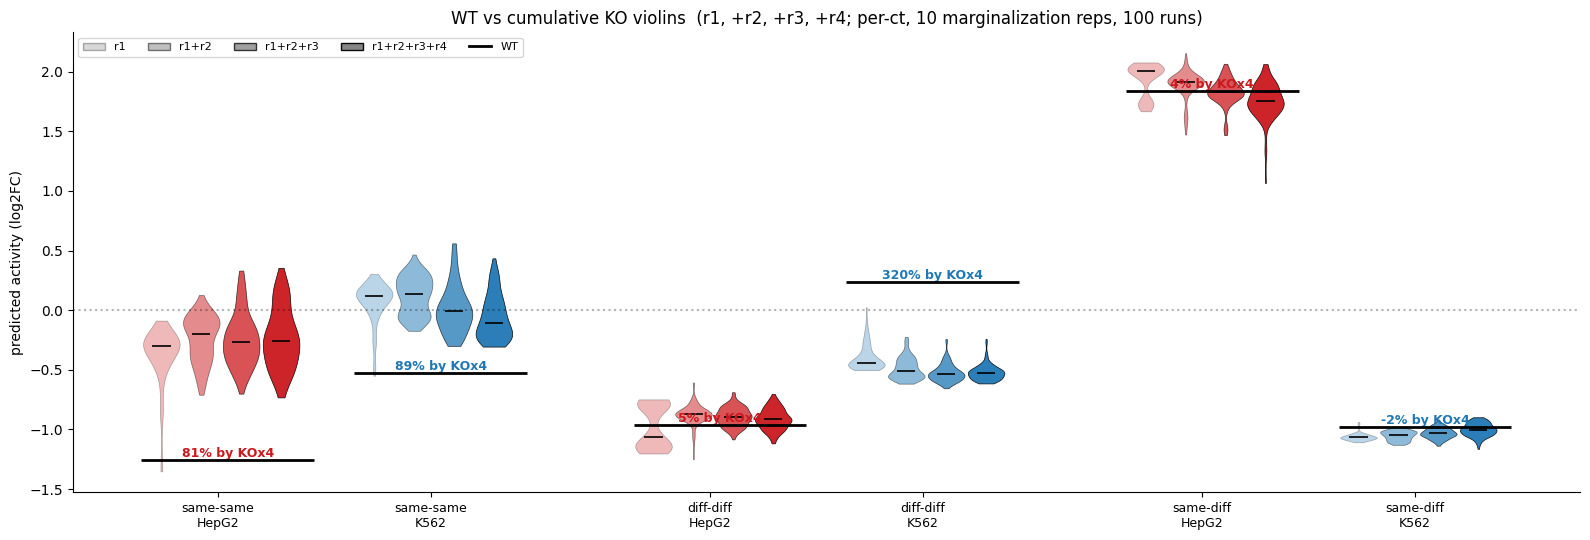

In [26]:
# cumulative KO viz (round 4): per (seq, ct) -> WT line + 4 violins (r1, +r2, +r3, +r4)
ko_cum4 = {ct: {name: {'r1': [], 'r12': [], 'r123': [], 'r1234': []}
                for name, _ in groups} for ct in CTS}

for name, idx in groups:
    wt = em.X[idx:idx+1].float()
    for ct in CTS:
        for run_i in range(N_RUNS):
            w1 = int(winners [name][ct][run_i])
            w2 = int(winners2[name][ct][run_i])
            w3 = int(winners3[name][ct][run_i])
            w4 = int(winners4[name][ct][run_i])
            shuf = dinuc_shuf(wt, n=N_REPS_KO,
                              random_state=int(idx)*9999 + run_i)[0]
            base = wt.expand(N_REPS_KO, -1, -1)
            for tag, wins in [('r1',    [w1]),
                              ('r12',   [w1, w2]),
                              ('r123',  [w1, w2, w3]),
                              ('r1234', [w1, w2, w3, w4])]:
                chim = base.clone()
                for w in wins:
                    chim[:, :, w:w+WIN] = shuf[:, :, w:w+WIN]
                p = em._predict_tensor(chim, models=models, batch_size=128)[ct]
                ko_cum4[ct][name][tag].append(float(p.mean()))
        for tag in ('r1', 'r12', 'r123', 'r1234'):
            ko_cum4[ct][name][tag] = np.array(ko_cum4[ct][name][tag])
        print(f'{name} {ct}: WT={wt_acts[ct][name]:.2f}  '
              f"r1={ko_cum4[ct][name]['r1'].mean():.2f}  "
              f"+r2={ko_cum4[ct][name]['r12'].mean():.2f}  "
              f"+r3={ko_cum4[ct][name]['r123'].mean():.2f}  "
              f"+r4={ko_cum4[ct][name]['r1234'].mean():.2f}")

# --- plot ---
order = ['same-same', 'diff-diff', 'same-diff']
ct_color = {'HepG2': '#cb181d', 'K562': '#1f77b4'}
tags = ['r1', 'r12', 'r123', 'r1234']
tag_alpha = {'r1': 0.3, 'r12': 0.5, 'r123': 0.75, 'r1234': 0.95}
tag_label = {'r1': 'r1', 'r12': 'r1+r2', 'r123': 'r1+r2+r3', 'r1234': 'r1+r2+r3+r4'}

fig, ax = plt.subplots(figsize=(16, 5.5))
xticks_main, xlabels_main = [], []
BUCKET_W = 3.2
GAP = 1.0

for i, name in enumerate(order):
    for j, ct in enumerate(CTS):
        center = i*(2*BUCKET_W + GAP) + j*BUCKET_W
        xticks_main.append(center + 0.85)
        xlabels_main.append(f'{name}\n{ct}')

        wt_v = wt_acts[ct][name]
        ko1234_mean = ko_cum4[ct][name]['r1234'].mean()
        pct = 100.0 * (wt_v - ko1234_mean) / wt_v if wt_v != 0 else float('nan')

        ax.hlines(wt_v, center - 0.3, center + 2.3, color='black',
                  linewidth=2, zorder=6)

        for k, tag in enumerate(tags):
            x = center + k*0.6
            v = ax.violinplot([ko_cum4[ct][name][tag]], positions=[x],
                              widths=0.55, showmeans=False, showmedians=True,
                              showextrema=False)
            for body in v['bodies']:
                body.set_facecolor(ct_color[ct])
                body.set_alpha(tag_alpha[tag])
                body.set_edgecolor('black'); body.set_linewidth(0.5)
            v['cmedians'].set_color('black'); v['cmedians'].set_linewidth(1.2)

        ax.text(center + 1.0, wt_v, f'{pct:.0f}% by KOx4',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=ct_color[ct])

ax.set_xticks(xticks_main); ax.set_xticklabels(xlabels_main, fontsize=9)
ax.axhline(0.0, color='k', ls=':', alpha=0.3)
ax.set_ylabel('predicted activity (log2FC)')
ax.set_title(f'WT vs cumulative KO violins  (r1, +r2, +r3, +r4; '
             f'per-ct, {N_REPS_KO} marginalization reps, {N_RUNS} runs)')

from matplotlib.patches import Patch
handles = [Patch(facecolor='gray', alpha=tag_alpha[t], edgecolor='black',
                 label=tag_label[t]) for t in tags]
handles.append(plt.Line2D([0], [0], color='black', linewidth=2, label='WT'))
ax.legend(handles=handles, loc='best', fontsize=8, ncol=5)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()
